Status: exploratory

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str((Path("..") / ".." / "src" / "utils").resolve()))
import blade
import micron_comparison
import visium_hd

plt.rcParams['svg.fonttype'] = 'none'

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Paths & datasets

MICrONS connectome (row 1, unchanged) plus a comprehensive border-effect
analysis across **all 12** available Visium HD / STOmics samples (4 public
10x Visium HD demo datasets, 4 in-house Visium HD spaceranger runs, 4 STOmics
custom experiments) — see `src/figure4/sample_manifest.csv`, the single
source of truth shared with `src/figure4/process_sample.py` and the SLURM
array job (`jobs/figure4_border_analysis.sbatch`) for running this
analysis in parallel, including on another cluster.

Each sample is further split into its individual spatially-connected
components (>100 bins) — e.g. a tissue microarray yields one row per core,
not one pooled row for the whole slide — since pooling border distances
across physically disconnected tissue is not meaningful (see
`visium_hd._border_fit_from_adata`'s docstring). For each component, both a
piecewise-linear fit (identifies a discrete buffer/exclusion zone) and an
exponential-saturation fit (a smooth, diffusion-interpretable correction)
are computed. For rows 2–4 of the combined figure, one representative
component per dataset type is picked automatically — the one whose
piecewise-linear elbow is closest to that type's median elbow — see "Select
example per dataset type" below.

In [3]:
with open("../../fit_palette.json") as f:
    pal = json.load(f)
BSPBLUE = pal["Piecewise Linear Fit"]
EXPSAT_COLOR = pal["Exponential Saturation Fit"]

# TODO: point at this checkout's actual MICrONS connectome file — still a
# je30bery-only path, see ../../STORY.md Key Result #4
MICRONS_FN_MAT = "/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/data/reimann_data/microns_mm3_connectome.h5"

SAVE_SVG = "../../result_plots/figure4/figure4_combined.svg"
SAVE_PDF = "../../result_plots/figure4/figure4_combined.pdf"

In [4]:
MANIFEST_PATH = "../../src/figure4/sample_manifest.csv"
PER_SAMPLE_DIR = Path("../../results/figure4/per_sample")

LOADERS = {"visium": visium_hd.analyze_dataset, "stomics": visium_hd.analyze_stomics_dataset}

# Single source of truth, shared with process_sample.py and the SLURM array
# job -- editing this file (not this cell) is how you add/change samples.
ALL_SAMPLES = pd.read_csv(MANIFEST_PATH)
ALL_SAMPLES

,name,dataset_type,loader,h5ad_path,bin_size_um
0,breast_cancer,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0
1,pancreas,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0
2,colon_cancer_ff,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0
3,breast_cancer_tma,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0
4,Pat1,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0
5,Pat2,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0
6,Pat3,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0
7,Pat4,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0
8,A02991D1,stomics_custom,stomics,/home/woody/iwbn/iwbn007h/spatial_data/stomics...,10.0
9,A02994C6,stomics_custom,stomics,/home/woody/iwbn/iwbn007h/spatial_data/stomics...,10.0


## Compute

`micron_comparison.prepare_microns_data` (row 1) is unchanged. For rows 2–4,
each of the 12 samples in `ALL_SAMPLES` is processed by
`src/figure4/process_sample.py` (`visium_hd.analyze_dataset` /
`analyze_stomics_dataset` → `visium_hd.summarize_all`, which includes the
BLADE peel-sweep) — either locally, or via the SLURM array job on another
cluster; either way the result lands as one JSON per sample under
`results/figure4/per_sample/`. The cell below reads whatever's there.

In [5]:
microns_data = micron_comparison.prepare_microns_data(MICRONS_FN_MAT)
micron_comparison.print_comparison_summary(microns_data["comparison"])

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/src/utils/micron_comparison.py:79: RuntimeWarning: invalid value encountered in divide
  C.add_vertex_property("outer_syn_fraction", outer_per_neuron / C.vertices["indegree"].values)


                                 bosperrus  Reimann (neuron)  Reimann (bin)
Neurons affected                    38,777            19,522         36,497
  (% of total)                       65.2%             32.8%          61.4%

Jaccard vs bosperrus
  Reimann per-neuron : 0.500
  Reimann per-bin    : 0.831


## Master results table (all samples, one row per connected component)

Reads `results/figure4/per_sample/<name>.json` for each sample in
`ALL_SAMPLES` (produced by `process_sample.py`, run either locally or via
the SLURM array job on another cluster). Each file is a JSON *array*, one
row per spatially-connected component with >100 bins found in that
sample — a TMA yields dozens of rows (one per core), a single contiguous
section usually yields a handful (the main tissue piece plus small
torn-off fragments). Missing samples are reported, not silently computed
inline here: the largest samples (>1M bins) can exceed this login node's
memory when run directly — run them via an interactive job or the SLURM
array instead, then re-run this cell.

In [6]:
rows = []
missing = []
for _, sample in ALL_SAMPLES.iterrows():
    json_path = PER_SAMPLE_DIR / f"{sample['name']}.json"
    if json_path.exists():
        with open(json_path) as f:
            rows.extend(json.load(f))  # one file -> one row per connected component
    else:
        missing.append(sample["name"])

master_table = pd.DataFrame(rows)
if missing:
    print(f"Missing {len(missing)}/{len(ALL_SAMPLES)} samples (not yet processed): {missing}")
print(f"{len(master_table)} component rows across {master_table['parent_sample'].nunique()} samples")

os.makedirs("../../results/figure4", exist_ok=True)
master_table.to_csv("../../results/figure4/border_effect_summary.csv", index=False)
master_table

132 component rows across 12 samples


,name,dataset_type,bin_size_um,component_id,component_size,n_bins,n_border_bins,const_c,const_AIC,pl_best_fit_type,...,exp_lambda_gridstep,exp_lambda_per_um,exp_decay_length_gridstep,exp_decay_length_um,aic_best_model,blade_buffer_raw_grid_steps,blade_buffer_raw_um,blade_buffer_exp_sat_corrected_grid_steps,blade_buffer_exp_sat_corrected_um,parent_sample
0,breast_cancer_c0,visium_demo,8.0,0,1458864,1458864,6423,5.848893,2.738210e+06,Piecewise Linear Fit,...,0.127989,0.015999,7.813157,62.505257,ExponentialSaturation,54.0,432.0,3.0,24.0,breast_cancer
1,breast_cancer_c4,visium_demo,8.0,4,1382,1382,163,4.564430,2.667371e+03,Piecewise Linear Fit,...,0.391282,0.048910,2.555704,20.445631,PiecewiseLinear,6.0,48.0,1.0,8.0,breast_cancer
2,breast_cancer_c11,visium_demo,8.0,11,1164,1164,216,5.039597,3.001744e+03,Piecewise Linear Fit,...,0.544239,0.068030,1.837427,14.699417,PiecewiseLinear,5.0,40.0,1.0,8.0,breast_cancer
3,breast_cancer_c15,visium_demo,8.0,15,624,624,99,4.668503,1.581847e+03,Piecewise Linear Fit,...,0.559129,0.069891,1.788496,14.307966,PiecewiseLinear,4.0,32.0,1.0,8.0,breast_cancer
4,breast_cancer_c2,visium_demo,8.0,2,475,475,188,3.726796,8.464327e+02,Piecewise Linear Fit,...,0.651654,0.081457,1.534557,12.276453,ExponentialSaturation,3.0,24.0,1.0,8.0,breast_cancer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,Y01084J8_c18,stomics_custom,10.0,18,866,866,110,5.275985,2.078924e+03,Piecewise Linear Fit,...,1.132150,0.113215,0.883275,8.832752,ExponentialSaturation,6.0,60.0,1.0,10.0,Y01084J8
128,Y01084J8_c16,stomics_custom,10.0,16,365,365,87,4.820363,9.545991e+02,Piecewise Linear Fit,...,1.266278,0.126628,0.789716,7.897162,ExponentialSaturation,5.0,50.0,1.0,10.0,Y01084J8
129,Y01084J8_c17,stomics_custom,10.0,17,347,347,74,5.625577,9.815922e+02,Piecewise Linear Fit,...,0.772945,0.077294,1.293754,12.937536,ExponentialSaturation,NaN,NaN,1.0,10.0,Y01084J8
130,Y01084J8_c1,stomics_custom,10.0,1,233,233,77,4.490153,6.080494e+02,Piecewise Linear Fit,...,1.217697,0.121770,0.821222,8.212224,ExponentialSaturation,NaN,NaN,1.0,10.0,Y01084J8


## Select example per dataset type (median elbow)

Picks, per dataset type, the **component whose piecewise-linear elbow
(`pl_elbow_um`) is closest to that type's median elbow** — restricted to
components with `component_size > MIN_SELECTION_SIZE` (see the empty gap in
the size histogram explored above, ~3,000-5,000 bins separating junk
fragments from real tissue pieces/TMA cores). Without this floor, the
median itself gets pulled into junk territory (junk fragments outnumber
real tissue components in most types), so "closest to median" ends up
picking a junk fragment just as easily as the plain-max-affected ranking
did — confirmed empirically (`Pat2_c9`, 103 bins, landed almost exactly on
`visium_custom`'s unrestricted median). All >100-bin components still stay
in `master_table`/the CSV either way; this floor only restricts which ones
are *eligible to be picked* for the figure. If any sample's JSON is still
missing (see the warning above), the median is only as representative as
what's been processed so far.

In [7]:
MIN_SELECTION_SIZE = 4000  # empty gap in the size histogram (~3000-5000 bins) separates junk from real tissue

eligible = master_table[master_table["component_size"] > MIN_SELECTION_SIZE]

group_medians = eligible.groupby("dataset_type")["pl_elbow_um"].median()
print(f"Median pl_elbow_um per dataset type (components > {MIN_SELECTION_SIZE} bins only):")
print(group_medians.to_string())
print()

deviation_from_median = (
    eligible["pl_elbow_um"] - eligible.groupby("dataset_type")["pl_elbow_um"].transform("median")
).abs()
selected_idx = deviation_from_median.groupby(eligible["dataset_type"]).idxmin()
selected = eligible.loc[selected_idx]

print("Selected (component with elbow closest to its type's median, size-eligible only):")
print(selected[["dataset_type", "name", "parent_sample", "component_size",
                 "pl_elbow_um", "pl_affected_pct"]].to_string(index=False))

TITLES = {
    "visium_demo": "Visium demo",
    "visium_custom": "Visium custom",
    "stomics_custom": "STOmics",
}

EXAMPLE_DATASETS = []
for _, row in selected.iterrows():
    manifest_row = ALL_SAMPLES.set_index("name").loc[row["parent_sample"]]
    EXAMPLE_DATASETS.append({
        "name": row["name"],
        "parent_sample": row["parent_sample"],
        "component_id": int(row["component_id"]),
        "title": f"{TITLES[row['dataset_type']]}: {row['name']} (elbow={row['pl_elbow_um']:.0f}µm)",
        "h5ad": manifest_row["h5ad_path"],
        "loader": LOADERS[manifest_row["loader"]],
        "bin_size_um": manifest_row["bin_size_um"],
    })
EXAMPLE_DATASETS

Median pl_elbow_um per dataset type (components > 4000 bins only):
dataset_type
stomics_custom    24.955132
visium_custom     99.235660
visium_demo       39.239418

Selected (component with elbow closest to its type's median, size-eligible only):
  dataset_type                 name     parent_sample  component_size  pl_elbow_um  pl_affected_pct
stomics_custom          A02994C6_c6          A02994C6           17216    25.351493        12.865939
 visium_custom              Pat4_c1              Pat4           32169    99.235660        39.102863
   visium_demo breast_cancer_tma_c5 breast_cancer_tma           10636    39.239418        39.140654


[{'name': 'A02994C6_c6',
  'parent_sample': 'A02994C6',
  'component_id': 6,
  'title': 'STOmics: A02994C6_c6 (elbow=25µm)',
  'h5ad': '/home/woody/iwbn/iwbn007h/spatial_data/stomics/A02994C6.bin20_1.0.h5ad',
  'loader': <function visium_hd.analyze_stomics_dataset(h5ad_path, bin_size=20, min_component_size=100)>,
  'bin_size_um': np.float64(10.0)},
 {'name': 'Pat4_c1',
  'parent_sample': 'Pat4',
  'component_id': 1,
  'title': 'Visium custom: Pat4_c1 (elbow=99µm)',
  'h5ad': '/home/woody/iwbn/iwbn007h/spatial_data/visium_custom/Pat4_008um_filtered.h5ad',
  'loader': <function visium_hd.analyze_dataset(h5ad_path, min_component_size=100)>,
  'bin_size_um': np.float64(8.0)},
 {'name': 'breast_cancer_tma_c5',
  'parent_sample': 'breast_cancer_tma',
  'component_id': 5,
  'title': 'Visium demo: breast_cancer_tma_c5 (elbow=39µm)',
  'h5ad': '/home/woody/iwbn/iwbn007h/spatial_data/visium/breast_cancer_tma_008um_filtered.h5ad',
  'loader': <function visium_hd.analyze_dataset(h5ad_path, min_com

In [8]:
example_results = {}
example_all_components = {}
for cfg in EXAMPLE_DATASETS:
    components = cfg["loader"](cfg["h5ad"])  # every component of the parent sample
    example_all_components[cfg["name"]] = components  # row 3 (whole-sample view) needs all of them
    example_results[cfg["name"]] = next(  # rows 2/4 (single-component fit/BLADE) only need this one
        r for r in components if r["component_id"] == cfg["component_id"]
    )

INFO     Creating graph using `None` transform and `1` libraries.                                                  


INFO     Creating graph using `None` transform and `1` libraries.                                                  


INFO     Creating graph using `None` transform and `1` libraries.                                                  


## Whole-sample overview (median-affected sample, all components)

The 3 panels above zoom into one component each. To also show what an
entire ST slide looks like with every component plotted together (row 5 of
the combined figure below), pick **one sample** (across all 12, not per
dataset type) whose components' *average* `pl_affected_pct` is closest to
the median of all 12 samples' per-sample averages — a "typical" sample
rather than an extreme one.

In [9]:
sample_avg_affected = master_table.groupby("parent_sample")["pl_affected_pct"].mean().sort_values()
print("Average pl_affected_pct per sample:")
print(sample_avg_affected.to_string())

median_avg = sample_avg_affected.median()
median_sample_name = (sample_avg_affected - median_avg).abs().idxmin()
print(f"\nMedian-average sample: {median_sample_name} "
      f"(avg={sample_avg_affected[median_sample_name]:.1f}%, "
      f"overall median-of-averages={median_avg:.1f}%)")

median_sample_manifest_row = ALL_SAMPLES.set_index("name").loc[median_sample_name]
whole_sample_components = LOADERS[median_sample_manifest_row["loader"]](median_sample_manifest_row["h5ad_path"])
print(f"loaded {len(whole_sample_components)} component(s) for {median_sample_name}")

Average pl_affected_pct per sample:
parent_sample
A02991D1              3.393843
Y01087DD             18.629595
A02994C6             29.950333
breast_cancer_tma    34.520699
Y01084J8             40.106393
Pat3                 44.765085
Pat1                 49.835679
Pat4                 58.344467
Pat2                 59.865705
pancreas             64.041436
breast_cancer        65.373468
colon_cancer_ff      83.726482

Median-average sample: Pat3 (avg=44.8%, overall median-of-averages=47.3%)


INFO     Creating graph using `None` transform and `1` libraries.                                                  


loaded 8 component(s) for Pat3


## Selected examples' summary

Subset of the master table (already computed above) for just the 3 examples
going into the figure. `pl_elbow_um`/`exp_decay_length_um` are both µm
conversions of their respective grid-step-native parameters
(`pl_elbow_grid_steps`, `exp_decay_length_gridstep`) using each sample's own
`bin_size_um` — see `visium_hd.exp_sat_diffusion_params`'s docstring for the
γ/β/λ derivation.

In [10]:
selected_names = [cfg["name"] for cfg in EXAMPLE_DATASETS]
summary = master_table[master_table["name"].isin(selected_names)]
summary

,name,dataset_type,bin_size_um,component_id,component_size,n_bins,n_border_bins,const_c,const_AIC,pl_best_fit_type,...,exp_lambda_gridstep,exp_lambda_per_um,exp_decay_length_gridstep,exp_decay_length_um,aic_best_model,blade_buffer_raw_grid_steps,blade_buffer_raw_um,blade_buffer_exp_sat_corrected_grid_steps,blade_buffer_exp_sat_corrected_um,parent_sample
49,breast_cancer_tma_c5,visium_demo,8.0,5,10636,10636,904,1.884733,26775.710467,Piecewise Linear Fit,...,0.390878,0.048860,2.558346,20.466768,PiecewiseLinear,7.0,56.0,1.0,8.0,breast_cancer_tma
107,Pat4_c1,visium_custom,8.0,1,32169,32169,946,3.957574,123100.294313,Piecewise Linear Fit,...,0.174856,0.021857,5.718996,45.751971,PiecewiseLinear,15.0,120.0,3.0,24.0,Pat4
110,A02994C6_c6,stomics_custom,10.0,6,17216,17216,671,3.432707,33047.698460,Piecewise Linear Fit,...,0.714533,0.071453,1.399515,13.995147,ExponentialSaturation,7.0,70.0,1.0,10.0,A02994C6


## BLADE comparison

`blade.peel_sweep` (see `src/utils/blade.py`) peels grid-NN<4 border layers
one at a time and Welch-t-tests each layer against the remaining interior,
for raw counts vs. counts corrected with the **exponential-saturation**
model specifically (`visium_hd.blade_comparison`) — not whichever fit AIC
happened to prefer. This is the buffer-zone-vs-smooth-correction narrative in
practice: piecewise-linear already told us *where* the discrete
buffer/exclusion zone is (its elbow); BLADE here shows that exp-sat's smooth
correction shrinks — often dramatically — how many border layers still look
statistically different from the interior, for all 12 samples
(`master_table`'s `blade_buffer_raw_um` vs. `blade_buffer_exp_sat_corrected_um`)
and for the 3 selected examples plotted below.

In [11]:
blade_results = {
    cfg["name"]: visium_hd.blade_comparison(example_results[cfg["name"]])
    for cfg in EXAMPLE_DATASETS
}

comparison_table = pd.DataFrame([
    {"dataset": name, "counts": label, "blade_buffer_grid_steps": buffer}
    for name, (_, buffers) in blade_results.items()
    for label, buffer in buffers.items()
]).pivot_table(index="dataset", columns="counts", values="blade_buffer_grid_steps")
comparison_table

counts,exp_sat_corrected,raw
dataset,,
A02994C6_c6,1.0,7.0
Pat4_c1,3.0,15.0
breast_cancer_tma_c5,1.0,7.0


## Combined figure (5 rows × 3 columns)

Row 1: MICrONS (degree-only fit, gray points / bspblue fit; boundary heatmap
as-is, spanning cols 2–3) — unchanged.

Columns are the 3 auto-selected most-affected examples (one per dataset
type; see `EXAMPLE_DATASETS` above).

Row 2: counts vs. distance to tissue border, with **both** fits overlaid —
piecewise-linear (bspblue, discrete buffer zone + elbow) and
exponential-saturation (`EXPSAT_COLOR`, smooth curve) — regardless of which
one AIC prefers for that sample.

Row 3: **whole-sample** spatial map (every component of that example's
parent sample, not just the one selected component — `example_all_components`)
colored by how much the exponential-saturation model would correct each bin,
on top of a grayscale base layer of the actual log1p(total_counts) (so real
tissue/count structure stays visible everywhere, not just where correction
applies). Correction color/alpha use a percentile-robust scale
(`_correction_color_range`) shared across all of a sample's components, so
one degenerate small fragment's fit can't hijack the whole panel's scale —
confirmed necessary empirically. The piecewise-linear elbow is drawn as an
**unfilled contour outline** (bspblue) per component, around each one's own
buffer zone — mirrors row 1's own elbow-as-outline styling. No largest-
connected-component restriction, so disconnected tissue fragments all show
up together.

Row 4: BLADE peel comparison, raw (magenta) vs. exponential-saturation-
corrected (`EXPSAT_COLOR`, consistent with rows 2–3) — same
piecewise-linear-buffer-zone-vs-exp-sat-smooth-correction story, now shown
as "how many border layers still look statistically different from the
interior, before vs. after correction." Still uses the single selected
component per example (`example_results`), not the whole sample.

Row 5 (spans all 3 columns): every component of one *different* sample
plotted together (`whole_sample_components`) — the sample whose components'
average `pl_affected_pct` is closest to the median **across all 12 samples**
(not per dataset type, unlike the column examples above), so it reads as one
additional "typical" full ST slide example alongside the 3 dataset-type
comparisons in row 3.

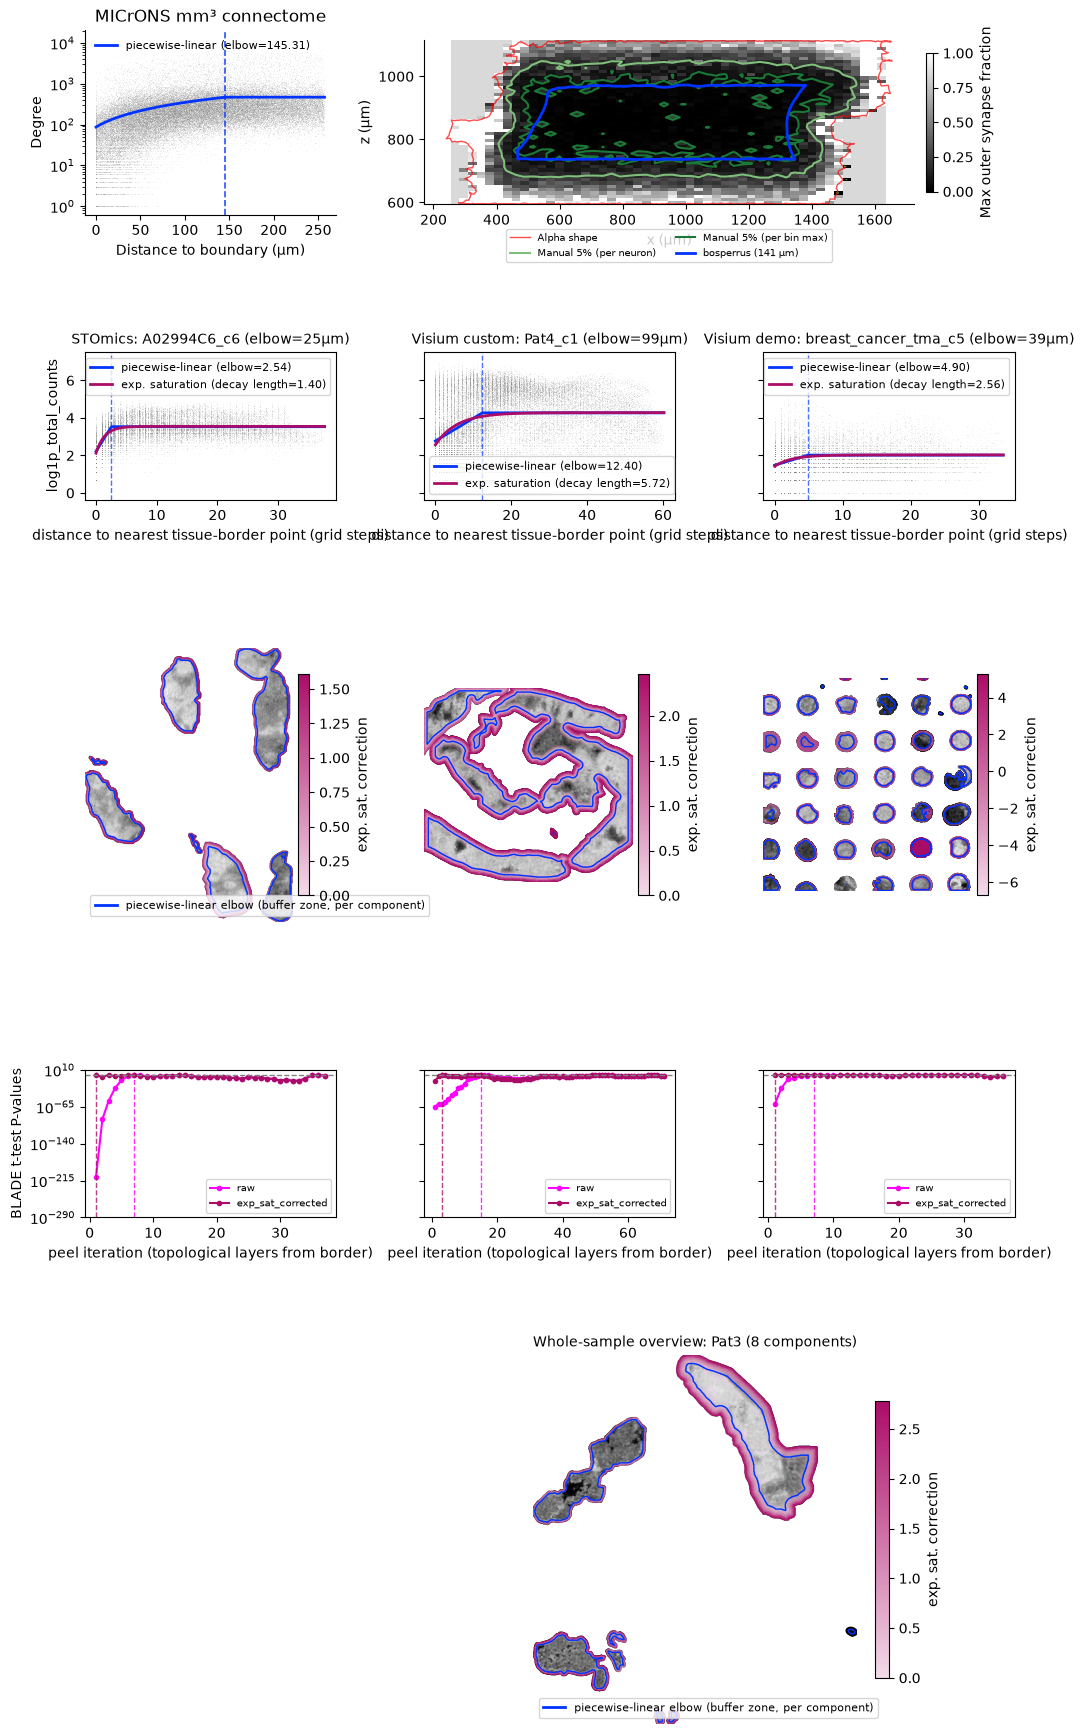

In [12]:
fig = plt.figure(figsize=(12, 22))
gs = fig.add_gridspec(5, 3, hspace=0.6, wspace=0.35, height_ratios=[1.25, 1, 2, 1, 2.5])

# unified scatter params for the row 1 / row 2 fit panels
SCATTER_SIZE, SCATTER_ALPHA, SCATTER_LINEWIDTHS = 0.3, 0.1, 0

# Row 1 — MICrONS: degree-only fit, plus the boundary heatmap "as is" (spanning cols 2-3)
ax_fit = fig.add_subplot(gs[0, 0])
micron_comparison.plot_fits_panel(
    ax_fit, microns_data["flow"], microns_data["alpha_distances"], microns_data["scores"],
    measures=["degree"], scatter_color="gray", fit_color=BSPBLUE,
    legend_label_fn=lambda measure, b, m, c: f"piecewise-linear (elbow={b/1e3:.2f})",
    ylabel="Degree",
    title="MICrONS mm³ connectome",
    scatter_size=SCATTER_SIZE, scatter_alpha=SCATTER_ALPHA, scatter_linewidths=SCATTER_LINEWIDTHS,
)

ax_heatmap = fig.add_subplot(gs[0, 1:])
micron_comparison.plot_boundary_heatmap_panel(
    ax_heatmap, microns_data,
    cmap="gray",
    boundary_label="Alpha shape", boundary_color="red",
    reimann_neuron_label="Manual 5% (per neuron)", reimann_neuron_color="#7FBF7B",
    reimann_bin_label="Manual 5% (per bin max)", reimann_bin_color="#1B7837",
    legend_bbox_to_anchor=(0.5, -0.15),
)

# Row 2 — one example per dataset type: counts vs. distance to tissue-border
# points (NN<4), both fits overlaid. Shared y across the row (same measure
# for all 3 examples); only col 0 keeps the label.
ax_row2_0 = None
for col, cfg in enumerate(EXAMPLE_DATASETS):
    ax = fig.add_subplot(gs[1, col], sharey=ax_row2_0)
    ax_row2_0 = ax_row2_0 or ax
    visium_hd.plot_counts_vs_distance_both_fits(
        ax, example_results[cfg["name"]], pl_color=BSPBLUE, exp_color=EXPSAT_COLOR,
        title=cfg["title"], ylabel=None if col == 0 else "",
        scatter_size=SCATTER_SIZE, scatter_alpha=SCATTER_ALPHA, scatter_linewidths=SCATTER_LINEWIDTHS,
    )
    if col > 0:
        plt.setp(ax.get_yticklabels(), visible=False)

# Row 3 — whole-sample spatial map (every component of the parent sample, not
# just the one selected component) colored by exp-sat correction magnitude
# over a counts base layer, piecewise-linear elbow as an unfilled outline per
# component. Titles are shared with row 2 (same 3 examples, same column
# order), so we skip them here and on row 4.
for col, cfg in enumerate(EXAMPLE_DATASETS):
    ax = fig.add_subplot(gs[2, col])
    visium_hd.plot_correction_map_multi(
        ax, example_all_components[cfg["name"]], exp_color=EXPSAT_COLOR, boundary_color=BSPBLUE,
        add_legend=(col == 0),
    )

# Row 4 — BLADE peel comparison (raw = magenta, exp-sat-corrected = EXPSAT_COLOR).
# Shared y across the row (both are p-values on the same 0-1 scale). Welch
# t-tests on these huge samples routinely underflow to p ~ 1e-50 or smaller,
# which would otherwise stretch the axis and squash the region near alpha=0.05
# — ylim_bottom crops those out of view (they're still in sweep_df, just not drawn).
BLADE_YLIM_BOTTOM = 1e-290
blade_colors = {"raw": "magenta", "exp_sat_corrected": EXPSAT_COLOR}
ax_row4_0 = None
for col, cfg in enumerate(EXAMPLE_DATASETS):
    ax = fig.add_subplot(gs[3, col], sharey=ax_row4_0)
    ax_row4_0 = ax_row4_0 or ax
    sweep_df, _ = blade_results[cfg["name"]]
    blade.plot_peel_sweep(ax, sweep_df, ["raw", "exp_sat_corrected"], blade_colors,
                           ylabel="BLADE t-test P-values" if col == 0 else None,
                           ylim_bottom=BLADE_YLIM_BOTTOM)
    if col > 0:
        plt.setp(ax.get_yticklabels(), visible=False)

# Row 5 — whole-sample overview: every component of the median-average-affected
# sample (see "Whole-sample overview" above), spanning all 3 columns so it
# reads as one recognizable ST slide rather than a cramped single-column panel.
ax_whole_sample = fig.add_subplot(gs[4, :])
visium_hd.plot_correction_map_multi(
    ax_whole_sample, whole_sample_components, exp_color=EXPSAT_COLOR, boundary_color=BSPBLUE,
    title=f"Whole-sample overview: {median_sample_name} ({len(whole_sample_components)} components)",
    add_legend=True,
)

os.makedirs(os.path.dirname(SAVE_SVG), exist_ok=True)
fig.savefig(SAVE_SVG, bbox_inches="tight")
#fig.savefig(SAVE_PDF, bbox_inches="tight")
plt.show()